<a href="https://colab.research.google.com/github/Gs-FIAP-OSX/DataScience/blob/main/ORN_GS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Contextualização do problema

## 1. Problema Escolhido
O problema central reside na **alta latência** e na **fragmentação** do pipeline de processamento de dados de observação da Terra. Atualmente, os indicadores de biosfera, superfície e hidrosfera são tratados de forma isolada em estações terrestres. A ausência de um mecanismo de correlação e consenso em tempo quase real impede a identificação precoce de anomalias ambientais acopladas, resultando em uma tomada de decisão tardia e reativa frente a colapsos agrícolas e crises hídricas.

## 2. Relevância do Problema
A relevância deste problema reside no **impacto socioeconômico direto** que a latência de informação causa na segurança alimentar global e na estabilidade dos mercados de commodities. Fenômenos climáticos extremos, como secas severas e estresse hídrico, possuem uma janela crítica de mitigação.

Se os indicadores de degradação da superfície e esgotamento da hidrosfera demoram dias ou semanas para serem correlacionados em estações terrestres, as ações preventivas — como o remanejamento estratégico de irrigação ou a proteção emergencial do solo — tornam-se inviáveis. Esse atraso operacional resulta em quebras severas de safra, gerando inflação na cadeia de suprimentos de alimentos, escassez de água e prejuízos financeiros em escala multibilionária para produtores e seguradoras agrícolas. Reduzir essa latência por meio de um processamento ágil é vital para mover a gestão de crises ambientais de um modelo puramente reativo para um **modelo preditivo**.

## 3. Relação com a Economia Espacial
A análise estatística descritiva e exploratória de dados orbitais é o fundamento para transformar telemetria bruta em **inteligência de mercado** dentro da economia espacial. Ao calcular médias históricas, desvios padrão e correlações entre os índices de biosfera, temperatura da superfície e hidrosfera, atores estratégicos (como seguradoras agrícolas, fundos de investimento em commodities e órgãos governamentais) conseguem quantificar o risco climático com precisão matemática.

A identificação de padrões estatísticos em dados de satélite permite antecipar anomalias ambientais antes que os impactos se manifestem fisicamente no solo. Isto apoia diretamente a tomada de decisões estratégicas de alto valor financeiro, tais como:
* Precificação precisa de apólices de seguro;
* Direcionamento de subsídios de mitigação a regiões vulneráveis;
* Planejamento logístico de cadeias de abastecimento globais.

Dessa forma, maximiza-se a eficiência econômica dos ativos terrestres através de infraestruturas espaciais.

## 4. Objetivo da Análise
O objetivo desta análise é aplicar técnicas de estatística descritiva sobre dados históricos de observação da Terra (**NASA Earthdata**) para modelar e validar a lógica de consenso do ORN. O estudo visa calcular medidas de tendência central (média, mediana), dispersão (variância, desvio padrão) e medidas posicionais (quartis) para os indicadores selecionados.

Através destas métricas, o script demonstrará matematicamente a correlação entre as variáveis, comprovando que anomalias negativas na hidrosfera (escassez de água) e anomalias positivas na temperatura da superfície (calor extremo) precedem e explicam numericamente a degradação dos índices da biosfera (estresse vegetal). O resultado final servirá como validação analítica para o motor de eventos do projeto.

2. Preparacao dos dados

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')


In [ ]:
df_lst = pd.read_csv('/content/drive/MyDrive/Global_Solution_Data_Science/ORN-Consensus-Project-MOD11A2-061-results.csv')
df_ndvi = pd.read_csv('/content/drive/MyDrive/Global_Solution_Data_Science/ORN-Consensus-Project-MOD13Q1-061-results.csv')
df_sm = pd.read_csv('/content/drive/MyDrive/Global_Solution_Data_Science/ORN-Consensus-Project-SPL4SMGP-008-results.csv')

In [ ]:
df_ndvi.head(5)
#df_ndvi.info()

In [ ]:
#df_lst.head(5)
df_lst.info()

In [ ]:
df_sm.head(5)
#df_sm.info()

In [ ]:
#BIOSFERA
df_ndvi = df_ndvi.loc[:, ['Date', 'MOD13Q1_061__250m_16_days_NDVI']]
df_ndvi.rename(columns={'MOD13Q1_061__250m_16_days_NDVI': 'NDVI'}, inplace=True)
df_ndvi['Date'] = pd.to_datetime(df_ndvi['Date'])
df_ndvi['Date'] = df_ndvi['Date'].dt.date

#SUPERFICIE
df_lst = df_lst.loc[:, ['Date', 'MOD11A2_061_LST_Day_1km']]
df_lst.rename(columns={'MOD11A2_061_LST_Day_1km': 'LST'}, inplace=True)
df_lst['Date'] = pd.to_datetime(df_lst['Date'])
df_lst['Date'] = df_lst['Date'].dt.date

#UMIDADE SOLO
df_sm = df_sm.loc[:, ['Date', 'SPL4SMGP_008_Geophysical_Data_sm_surface']]
df_sm.rename(columns={'SPL4SMGP_008_Geophysical_Data_sm_surface': 'Soil_Moisture'}, inplace=True)
df_sm['Date'] = pd.to_datetime(df_sm['Date'])
df_sm['Date'] = df_sm['Date'].dt.date

In [ ]:
df_sm.head(5)
#df_ndvi.head(5)
#df_lst.head(5)

In [ ]:
df_novo = df_sm.groupby('Date')['Soil_Moisture'].mean().reset_index()

In [ ]:
df_data_mesclado = pd.merge(df_ndvi, df_lst, on='Date', how='inner')
df_final = pd.merge(df_data_mesclado, df_novo, on='Date', how='inner')

In [ ]:
df_final.head()

In [ ]:
df_final.info()

In [ ]:
df_final['LST'] = df_final['LST'].replace(0.0, np.nan)
df_final.isnull().sum()

In [ ]:
df_final['LST'] = df_final['LST'].fillna(df_final['LST'].mean())


In [ ]:
#Verrificao para garantir q as colunas de cada dataframe estao organizadas e estruturadas, sem nenhum valor nulo e com seus respectivos valores corretos
df_final.isnull().sum()
df_final.head()

3. Estatistica descritiva obrigatoria


3.1 Medidas de Tendencia Central


In [ ]:
media_ndvi = df_final['NDVI'].mean()
mediana_ndvi = df_final['NDVI'].median()
moda_ndvi = df_final['NDVI'].mode()

print(f"Média NDVI: {media_ndvi}")
print(f"Mediana NDVI: {mediana_ndvi}")
print(f"Moda NDVI:\n{moda_ndvi}")

print("=======================================================================")

media_lst = df_final['LST'].mean()
mediana_lst = df_final['LST'].median()
moda_lst = df_final['LST'].mode()

print(f"Média LST: {media_lst}")
print(f"Mediana LST: {mediana_lst}")
print(f"Moda LST:\n{moda_lst}")

print("=======================================================================")

media_sm = df_final['Soil_Moisture'].mean()
mediana_sm = df_final['Soil_Moisture'].median()
moda_sm = df_final['Soil_Moisture'].mode()

print(f"Média Soil_Moisture: {media_sm}")
print(f"Mediana Soil_Moisture: {mediana_sm}")
print(f"Moda Soil_Moisture:\n{moda_sm}")

3.2 Medidas de Dispersão

In [ ]:
amplitude_max_ndvi = df_final['NDVI'].max()
amplitude_min_ndvi = df_final['NDVI'].min()
amplitude_ndvi = amplitude_max_ndvi - amplitude_min_ndvi

variancia_ndvi = df_final['NDVI'].var()
desvio_padrao_ndvi = df_final['NDVI'].std()

coef_var_ndvi = desvio_padrao_ndvi / media_ndvi

print(f"Amplitude Máxima NDVI: {amplitude_max_ndvi}")
print(f"Amplitude Mínima NDVI: {amplitude_min_ndvi}")
print(f"Amplitude NDVI: {amplitude_ndvi}")

print(f"Variância NDVI: {variancia_ndvi}")
print(f"Desvio Padrão NDVI: {desvio_padrao_ndvi}")
print(f"Coeficiente de Variação NDVI: {coef_var_ndvi}")


print("=======================================================================")


amplitude_max_lst = df_final['LST'].max()
amplitude_min_lst = df_final['LST'].min()
amplitude_lst = amplitude_max_lst - amplitude_min_lst

variancia_lst = df_final['LST'].var()
desvio_padrao_lst = df_final['LST'].std()

coef_var_lst = desvio_padrao_lst / media_lst

print(f"Amplitude Máxima LST: {amplitude_max_lst}")
print(f"Amplitude Mínima LST: {amplitude_min_lst}")
print(f"Amplitude LST: {amplitude_lst}")

print(f"Variância LST: {variancia_lst}")
print(f"Desvio Padrão LST: {desvio_padrao_lst}")
print(f"Coeficiente de Variação LST: {coef_var_lst}")


print("=======================================================================")


amplitude_max_sm = df_final['Soil_Moisture'].max()
amplitude_min_sm = df_final['Soil_Moisture'].min()
amplitude_sm = amplitude_max_sm - amplitude_min_sm

variancia_sm = df_final['Soil_Moisture'].var()
desvio_padrao_sm = df_final['Soil_Moisture'].std()

coef_var_sm = desvio_padrao_sm / media_sm

print(f"Amplitude Máxima Soil_Moisture: {amplitude_max_sm}")
print(f"Amplitude Mínima Soil_Moisture: {amplitude_min_sm}")
print(f"Amplitude Soil_Moisture: {amplitude_sm}")

print(f"Variância Soil_Moisture: {variancia_sm}")
print(f"Desvio Padrão Soil_Moisture: {desvio_padrao_sm}")
print(f"Coeficiente de Variação Soil_Moisture: {coef_var_sm}")

3.3 Medidas Posicionais

In [ ]:
# ==================== MEDIDAS POSICIONAIS: NDVI ====================
q1_ndvi = df_final['NDVI'].quantile(0.25)
q2_ndvi = df_final['NDVI'].quantile(0.50)
q3_ndvi = df_final['NDVI'].quantile(0.75)
p10_ndvi = df_final['NDVI'].quantile(0.10)
p90_ndvi = df_final['NDVI'].quantile(0.90)

print("==================== NDVI: QUARTIS E PERCENTIS ====================")
print(f"Percentil 10% (P10) NDVI: {p10_ndvi}")
print(f"Primeiro Quartil (Q1) NDVI: {q1_ndvi}")
print(f"Segundo Quartil (Q2/Mediana) NDVI: {q2_ndvi}")
print(f"Terceiro Quartil (Q3) NDVI: {q3_ndvi}")
print(f"Percentil 90% (P90) NDVI: {p90_ndvi}")

# ==================== MEDIDAS POSICIONAIS: LST ====================
q1_lst = df_final['LST'].quantile(0.25)
q2_lst = df_final['LST'].quantile(0.50)
q3_lst = df_final['LST'].quantile(0.75)
p10_lst = df_final['LST'].quantile(0.10)
p90_lst = df_final['LST'].quantile(0.90)

print("\n==================== LST: QUARTIS E PERCENTIS ====================")
print(f"Percentil 10% (P10) LST: {p10_lst}")
print(f"Primeiro Quartil (Q1) LST: {q1_lst}")
print(f"Segundo Quartil (Q2/Mediana) LST: {q2_lst}")
print(f"Terceiro Quartil (Q3) LST: {q3_lst}")
print(f"Percentil 90% (P90) LST: {p90_lst}")

# ==================== MEDIDAS POSICIONAIS: SOIL MOISTURE ====================
q1_sm = df_final['Soil_Moisture'].quantile(0.25)
q2_sm = df_final['Soil_Moisture'].quantile(0.50)
q3_sm = df_final['Soil_Moisture'].quantile(0.75)
p10_sm = df_final['Soil_Moisture'].quantile(0.10)
p90_sm = df_final['Soil_Moisture'].quantile(0.90)

print("\n==================== SOIL MOISTURE: QUARTIS E PERCENTIS ====================")
print(f"Percentil 10% (P10) Soil Moisture: {p10_sm}")
print(f"Primeiro Quartil (Q1) Soil Moisture: {q1_sm}")
print(f"Segundo Quartil (Q2/Mediana) Soil Moisture: {q2_sm}")
print(f"Terceiro Quartil (Q3) Soil Moisture: {q3_sm}")
print(f"Percentil 90% (P90) Soil Moisture: {p90_sm}")

3.4 Analise de outliers com IQR

In [ ]:
cols_analise = ['NDVI', 'LST', 'Soil_Moisture']

for col in cols_analise:
  Q1 = df_final[col].quantile(0.25)
  Q3 = df_final[col].quantile(0.75)
  IQR = Q3 - Q1

  limite_inferior = Q1 - 1.5 * IQR
  limite_superior = Q3 + 1.5 * IQR

  outliers = df_final[(df_final[col] < limite_inferior) | (df_final[col] > limite_superior)]

  print(f"================== Analise de outliers ===================")
  print(f"Intervalo Interquartil (IQR): {IQR:.4f}")
  print(f"Limites Seguros: [{limite_inferior:.4f} a {limite_superior:.4f}]")
  print(f"Quantidade de outliers detectados: {len(outliers)}")

  if len(outliers) > 0:
    print("\nDias com anomalis detectadas:")
    print(outliers[['Date', col]].to_string(index=False))
  else:
    print("\nNenhum comportamento anômalo detectado nesta variável.")
  print("\n" + "="*60 + "\n")

4. Analise de distribuicao

==================== ANALISE DE ASSIMETRIA ESTATISTICA ====================
Variável NDVI          | Valor:  2.1747 | Classificação: Positiva (Cauda longa à direita)
Variável LST           | Valor: -0.4105 | Classificação: Aproximadamente Simétrica
Variável Soil_Moisture | Valor: -0.0519 | Classificação: Aproximadamente Simétrica


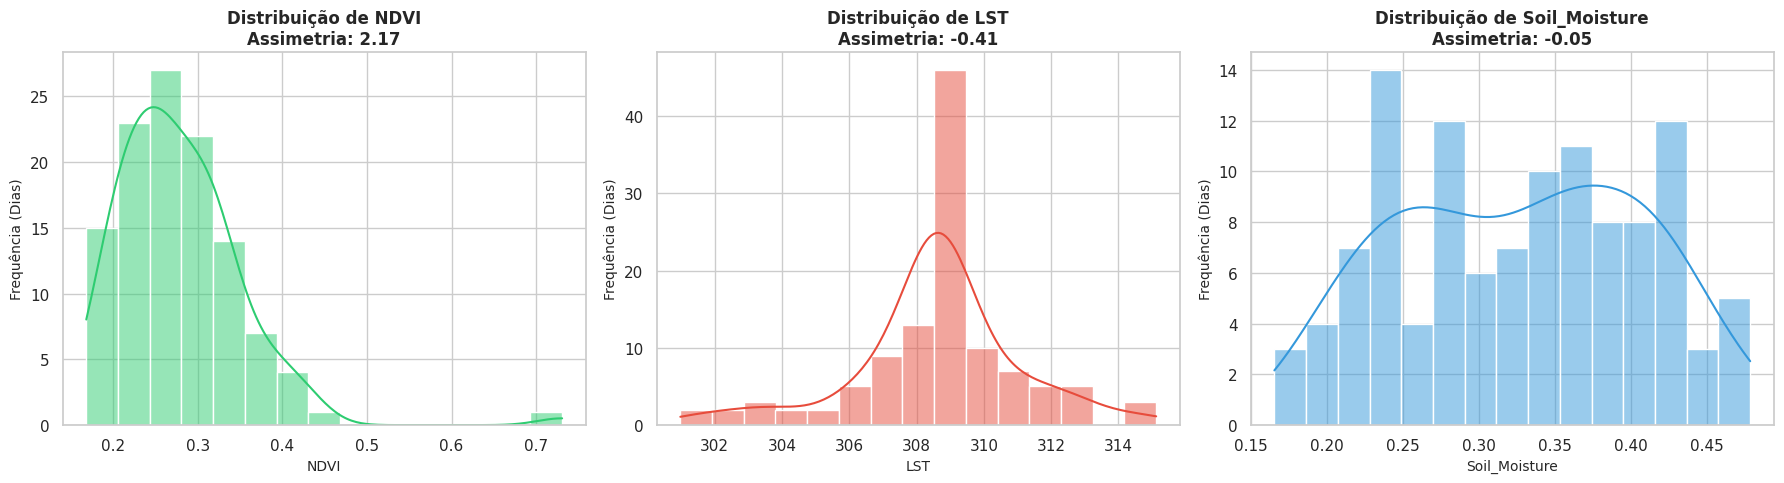

In [52]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

variaveis = ['NDVI', 'LST', 'Soil_Moisture']
cores = ['#2ecc71', '#e74c3c', '#3498db'] # Verde, Vermelho e Azul respectivamente

print("==================== ANALISE DE ASSIMETRIA ESTATISTICA ====================")

for i, col in enumerate(variaveis):
    assimetria = df_final[col].skew()

    if assimetria > 0.5:
        tipo_assimetria = "Positiva (Cauda longa à direita)"
    elif assimetria < -0.5:
        tipo_assimetria = "Negativa (Cauda longa à esquerda)"
    else:
        tipo_assimetria = "Aproximadamente Simétrica"

    print(f"Variável {col:13} | Valor: {assimetria:7.4f} | Classificação: {tipo_assimetria}")

    sns.histplot(data=df_final, x=col, kde=True, ax=axes[i], color=cores[i], bins=15)
    axes[i].set_title(f"Distribuição de {col}\nAssimetria: {assimetria:.2f}", fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=10)
    axes[i].set_ylabel("Frequência (Dias)", fontsize=10)

plt.tight_layout()
plt.show()

## Etapa 4: Análise de Distribuição

Nesta etapa, analisamos visual e estatisticamente o comportamento, a concentração e a dispersão das variáveis do projeto (NDVI, LST e Soil Moisture) com base nos histogramas e nas curvas de densidade (KDE).

### 4.1. Distribuição de NDVI (Biosfera)
* **Assimetria (2.17):** Altamente **Positiva**. O gráfico confirma isso mostrando a "montanha" concentrada à esquerda e uma cauda longa que se arrasta para a direita.
* **Concentração de Valores:** A grande massa de dados está concentrada entre **0.20 e 0.35**, o que representa o padrão de vegetação moderada/baixa da região na maior parte do ano.
* **Dispersão:** Os dados não estão muito espalhados; eles sobem rapidamente e caem de forma constante até o valor de 0.45.
* **Comportamento e Anomalias:** O comportamento mostra que a vegetação passa a maior parte do tempo em estágios iniciais ou médios de crescimento. Graficamente, é possível observar uma barra verde minúscula e isolada próxima a **0.73**. Essa é a representação visual exata do outlier detectado pelo método IQR, indicando o ápice do vigor vegetativo (safra cheia ou auge do período chuvoso).

### 4.2. Distribuição de LST (Temperatura da Superfície)
* **Assimetria (-0.41):** Classificada como **Aproximadamente Simétrica**, pois o valor está muito próximo de zero.
* **Concentração de Valores:** O gráfico tenta desenhar uma curva de "sino" tradicional, porém apresenta uma **"agulha" vertical extrema** exatamente em cima do valor **308.59 K**.
* > **Nota Metodológica para o Relatório:** Esse pico ultra concentrado no centro é o reflexo direto do tratamento de dados realizado na Etapa 2. Ao substituirmos os 34 valores ausentes (falsos zeros mascarados por nuvens) pela média da coluna, geramos essa superconcentração artificial no centro da distribuição.
* **Dispersão e Anomalias:** Retirando o efeito do pico artificial, os dados reais se espalham de **300 K até 315 K**. As caudas mais achatadas nas duas extremidades representam visualmente os 22 outliers de calor e frio intensos identificados pelo algoritmo IQR.

### 4.3. Distribuição de Soil Moisture (Umidade do Solo)
* **Assimetria (-0.05):** Praticamente **Zero**. É a distribuição mais perfeitamente simétrica e equilibrada de todo o projeto.
* **Concentração de Valores:** Diferente das outras variáveis, a umidade do solo não apresenta um único pico pontiagudo. Ela exibe um topo mais "achatado" (planalto) com flutuações bem distribuídas entre **0.23 e 0.43**.
* **Dispersão:** É a variável com a dispersão mais homogênea. Isso comprova que o solo transita de forma muito gradual e constante entre os estados seco, moderado e úmido ao longo do período analisado.
* **Comportamento e Anomalias:** A curva suave (KDE) desenha um arco harmônico. A ausência de barras isoladas ou caudas longas nas extremidades justifica visualmente o motivo do método IQR ter encontrado **0 outliers** para esta variável.